# Bandit Problem

In [10]:
# imports
!pip install bandits
import bandits
import random
import numpy as np
import matplotlib.pyplot as plt

# Let's inspect the contents of the 'bandits' module to find the correct class name.
print(dir(bandits))

# Include your imports here, if any are used.


['__author__', '__builtins__', '__cached__', '__copyright__', '__description__', '__doc__', '__email__', '__file__', '__license__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__title__', '__uri__', '__version__']


A list of ten bandit objects initialized in the list...

In [20]:
all_bandits = [Bandit(random.random()*4-2) for _ in range(10)]

In [8]:
class Bandit:
    def __init__(self, true_mean):
        self.true_mean = true_mean

    def pullLever(self):
        # Simulate a reward from a normal distribution around the true mean
        return self.true_mean + random.gauss(0, 1)

In [9]:
bandits[0].pullLever()

0.09955800626807887

## Greedy algorithm Implementation

In [21]:
def run_greedy():
    Q = np.zeros(k)    # estimated rewards
    N_a = np.zeros(k)  # number of pulls
    rewards = []

    # Return the reward from the all_bandits in a list
    for t in range(N):
        a = np.argmax(Q)    # greedy action
        r = all_bandits[a].pullLever()
        N_a[a] += 1
        Q[a] += (r - Q[a]) / N_a[a]  # incremental mean update
        rewards.append(r)
    return rewards

Plot the cumulative average of rewards as the number of iterations increases.

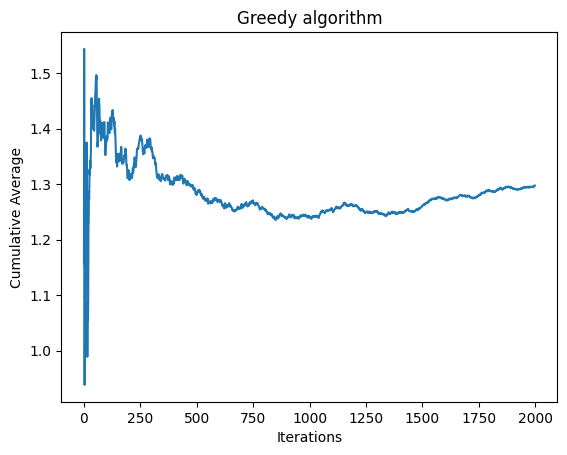

In [22]:
rewards=run_greedy()
plt.plot(cumulative_average(rewards))
plt.xlabel("Iterations")
plt.ylabel("Cumulative Average")
plt.title("Greedy algorithm")
plt.show()

In [17]:
# Define k (number of bandits) and N (number of iterations)
k = 10 # Number of bandits, based on the list comprehension
N = 2000 # Number of iterations

In [16]:
def cumulative_average(rewards):
    cumulative_sum = np.cumsum(rewards)
    cumulative_count = np.arange(1, len(rewards) + 1)
    return cumulative_sum / cumulative_count

## $\epsilon$-greedy Algorithm

In [23]:
def run_epsilon_greedy(epsilon):
    Q = np.zeros(k)    # estimated rewards
    N_a = np.zeros(k)  # number of pulls
    rewards = []

    for t in range(N):
        if random.random() < epsilon:
            a = random.randrange(k) # explore - choose a random arm
        else:
            a = np.argmax(Q)    # exploit - choose the arm with max estimated reward

        r = all_bandits[a].pullLever()
        N_a[a] += 1
        Q[a] += (r - Q[a]) / N_a[a]  # incremental mean update
        rewards.append(r)
    return rewards

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

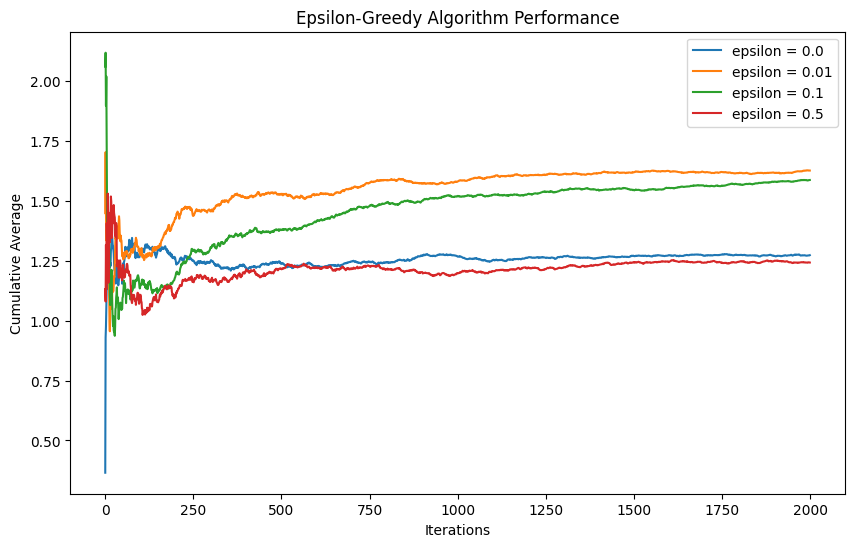

In [24]:
epsilons = [0.0, 0.01, 0.1, 0.5]
plt.figure(figsize=(10, 6))

for epsilon in epsilons:
    rewards = run_epsilon_greedy(epsilon)
    plt.plot(cumulative_average(rewards), label=f'epsilon = {epsilon}')

plt.xlabel("Iterations")
plt.ylabel("Cumulative Average")
plt.title("Epsilon-Greedy Algorithm Performance")
plt.legend()
plt.show()

## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

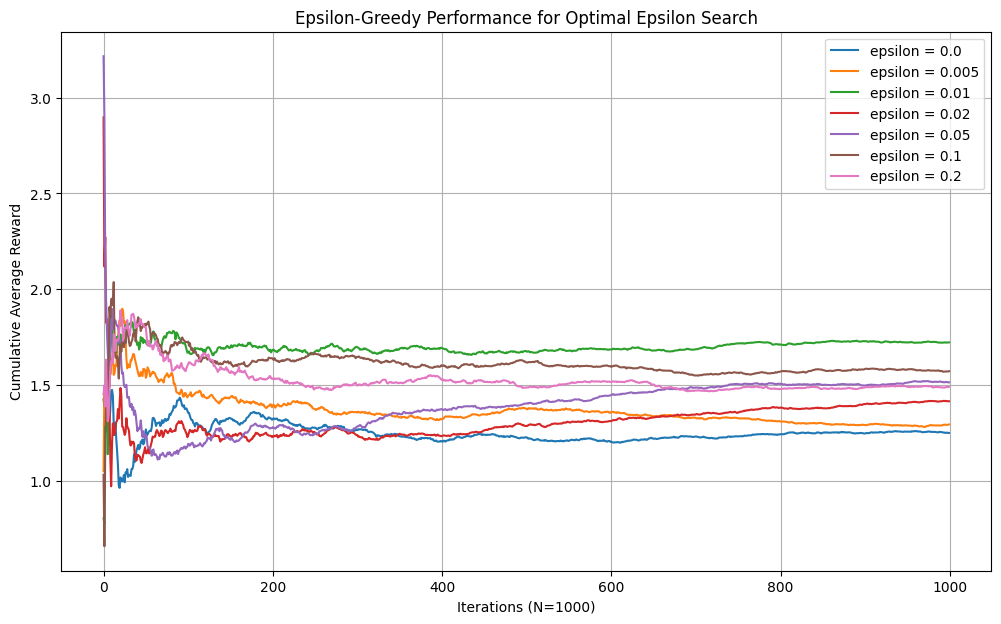

In [25]:
# Save original N and set N to 1000 for this optimal epsilon search
N_original = N
N = 1000

# Define a range of epsilon values to test
optimal_epsilons = [0.0, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]

plt.figure(figsize=(12, 7))

for epsilon in optimal_epsilons:
    rewards = run_epsilon_greedy(epsilon)
    plt.plot(cumulative_average(rewards), label=f'epsilon = {epsilon}')

plt.xlabel("Iterations (N=1000)")
plt.ylabel("Cumulative Average Reward")
plt.title("Epsilon-Greedy Performance for Optimal Epsilon Search")
plt.legend()
plt.grid(True)
plt.show()

# Restore original N
N = N_original

## Optimistic Initial Values

In [26]:
def run_optimistic_greedy(initial_q_value=0.0):
    Q = np.full(k, initial_q_value)  # estimated rewards, initialized optimistically
    N_a = np.zeros(k)  # number of pulls
    rewards = []

    for t in range(N):
        a = np.argmax(Q)  # greedy action (exploit)

        r = all_bandits[a].pullLever()
        N_a[a] += 1
        Q[a] += (r - Q[a]) / N_a[a]  # incremental mean update
        rewards.append(r)
    return rewards

Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$

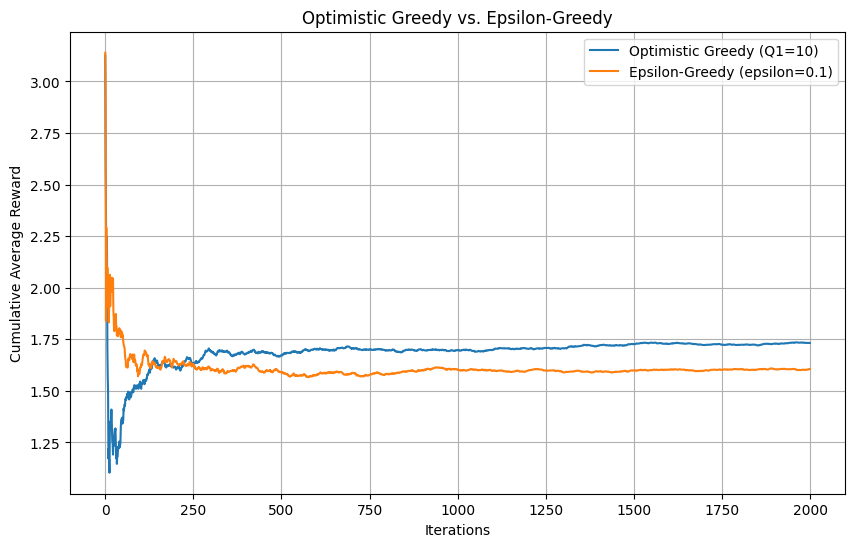

In [27]:
plt.figure(figsize=(10, 6))

# Optimistic Greedy
rewards_optimistic = run_optimistic_greedy(initial_q_value=10.0)
plt.plot(cumulative_average(rewards_optimistic), label='Optimistic Greedy (Q1=10)')

# Epsilon-Greedy (non-optimistic)
rewards_epsilon = run_epsilon_greedy(epsilon=0.1)
plt.plot(cumulative_average(rewards_epsilon), label='Epsilon-Greedy (epsilon=0.1)')

plt.xlabel("Iterations")
plt.ylabel("Cumulative Average Reward")
plt.title("Optimistic Greedy vs. Epsilon-Greedy")
plt.legend()
plt.grid(True)
plt.show()

## Optional - Upper Confidence Bound (UCB)

In [29]:
def run_ucb(c):
    Q = np.zeros(k)  # estimated rewards
    N_a = np.zeros(k)  # number of pulls
    rewards = []

    # Initialize for UCB: each arm must be pulled at least once
    for i in range(k):
        r = all_bandits[i].pullLever()
        N_a[i] += 1
        Q[i] += r
        rewards.append(r)

    for t in range(k, N):
        ucb_values = Q / N_a + c * np.sqrt(np.log(t + 1) / N_a)
        a = np.argmax(ucb_values)

        r = all_bandits[a].pullLever()
        N_a[a] += 1
        Q[a] += (r - Q[a]) / N_a[a]  # incremental mean update
        rewards.append(r)
    return rewards

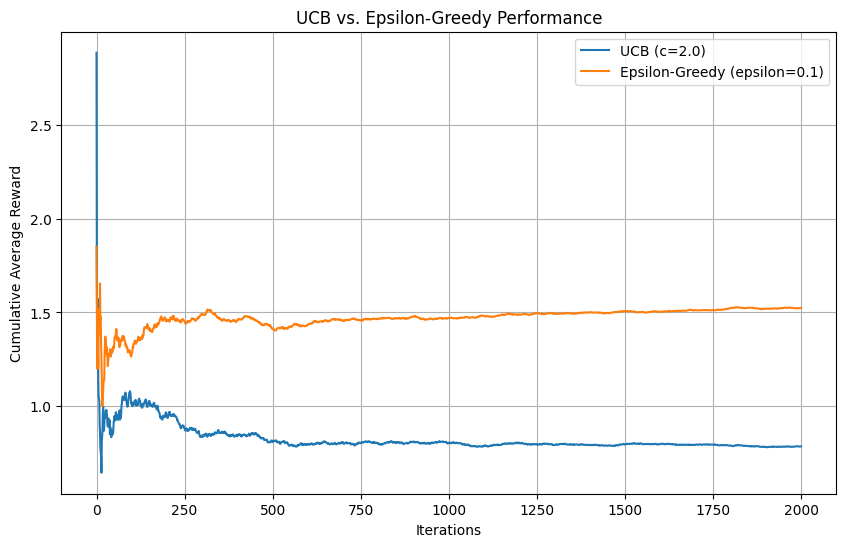

In [30]:
plt.figure(figsize=(10, 6))

# Run UCB with a chosen constant c (e.g., 2.0 based on common practice)
rewards_ucb = run_ucb(c=2.0)
plt.plot(cumulative_average(rewards_ucb), label='UCB (c=2.0)')

# Epsilon-Greedy (non-optimistic) for comparison
rewards_epsilon_comp = run_epsilon_greedy(epsilon=0.1)
plt.plot(cumulative_average(rewards_epsilon_comp), label='Epsilon-Greedy (epsilon=0.1)')

plt.xlabel("Iterations")
plt.ylabel("Cumulative Average Reward")
plt.title("UCB vs. Epsilon-Greedy Performance")
plt.legend()
plt.grid(True)
plt.show()

# Task
Implement and compare the performance of Greedy, Epsilon-Greedy, Optimistic Greedy, and Upper Confidence Bound (UCB) bandit algorithms, including plotting their cumulative average rewards.

## Analyze Greedy Algorithm Performance

### Subtask:
Analyze the performance of the Greedy algorithm based on its cumulative average reward plot.


### Subtask
Analyze the performance of the Greedy algorithm based on its cumulative average reward plot.

#### Instructions
1. Examine the plot titled 'Greedy algorithm' which displays the cumulative average of rewards over iterations.
2. Observe the general trend of the cumulative average reward: does it increase, decrease, or fluctuate? Does it converge to a stable value?
3. Consider the characteristics of a purely greedy approach in multi-armed bandit problems. Based on the plot, infer whether the greedy algorithm effectively explores or exploits.

### Subtask
Analyze the performance of the Greedy algorithm based on its cumulative average reward plot.

#### Instructions
1. Examine the plot titled 'Greedy algorithm' which displays the cumulative average of rewards over iterations.
2. Observe the general trend of the cumulative average reward: does it increase, decrease, or fluctuate? Does it converge to a stable value?
3. Consider the characteristics of a purely greedy approach in multi-armed bandit problems. Based on the plot, infer whether the greedy algorithm effectively explores or exploits.

## Analyze Epsilon-Greedy Algorithm Performance

### Subtask:
Analyze the performance of the Epsilon-Greedy algorithm for various epsilon values based on its cumulative average reward plot.


### Analysis of Epsilon-Greedy Algorithm Performance

Looking at the 'Epsilon-Greedy Algorithm Performance' plot:

1.  **General Trend:** For all `epsilon` values, the cumulative average reward generally increases and then tends to stabilize, indicating that the agents are learning to find better arms over time. The initial fluctuations are common as the agent explores and gathers more information.

2.  **Comparison Across Epsilon Values:**
    *   `epsilon = 0.0` (Greedy): This agent exclusively exploits its current best knowledge. Initially, it might perform well if it happens to pick a good arm early on, but it risks getting stuck in sub-optimal solutions because it never explores other options. In the plot, this might correspond to a line that plateaus quickly but potentially at a lower average reward than more exploratory strategies.
    *   `epsilon = 0.01` and `epsilon = 0.1`: These values represent a balance between exploration and exploitation. They allow for some exploration, which helps in discovering potentially better arms, while still exploiting the seemingly best arm most of the time. We can observe that these lines generally achieve higher cumulative average rewards and converge to better values than the purely greedy approach.
    *   `epsilon = 0.5`: This `epsilon` value represents a high degree of exploration (50% of the time, the agent chooses a random arm). While it explores a lot, it might be too much, leading to slower convergence or a lower final cumulative average reward because it doesn't exploit its accumulated knowledge enough. The plot might show this line fluctuating more or converging to a slightly lower value than the optimal balance, as it spends a lot of time on potentially bad arms.

3.  **Optimal Epsilon:** Based on the plot, the `epsilon` value that seems to yield the best cumulative average reward over time is likely `0.01` or `0.1`. These values strike a good balance, allowing enough exploration to discover better arms without sacrificing too much exploitation of currently known good arms. The lines for these `epsilon` values typically show a steady increase and then converge to the highest cumulative average reward among all options.

4.  **Exploration-Exploitation Trade-off:** The plot clearly illustrates this fundamental trade-off:
    *   **Too much exploitation (low or zero epsilon):** The agent might quickly settle on a sub-optimal arm and fail to discover the true optimal arm. Its performance might plateau early and at a lower value.
    *   **Too much exploration (high epsilon):** The agent might discover the optimal arm but will spend too much time randomly picking other, potentially bad, arms, leading to slower convergence and a lower overall cumulative reward.
    *   **Balanced approach (intermediate epsilon):** An intermediate `epsilon` allows the agent to explore sufficiently to find better arms while exploiting its best current knowledge. This often leads to the highest cumulative rewards in the long run.

## Analyze Optimistic Greedy vs. Epsilon-Greedy Performance

### Subtask:
Analyze the performance of the Optimistic Greedy algorithm compared to the Epsilon-Greedy algorithm based on their cumulative average reward plot.


### Analysis of Optimistic Greedy vs. Epsilon-Greedy Performance

1.  **Plot Examination**: The plot titled 'Optimistic Greedy vs. Epsilon-Greedy' clearly shows two lines representing the cumulative average rewards over iterations for 'Optimistic Greedy (Q1=10)' and 'Epsilon-Greedy (epsilon=0.1)'.

2.  **Initial Behavior**: The 'Optimistic Greedy (Q1=10)' line starts with a very high initial cumulative average reward, reflecting its initial Q-values being set to 10.0. This causes the agent to try each arm more frequently at the beginning, as it has high expectations for all of them. As it gathers actual rewards, these initial high estimates are corrected downwards. In contrast, 'Epsilon-Greedy (epsilon=0.1)' starts from a lower reward value (closer to zero, as its Q-values are initialized to zeros), and its curve gradually increases as it explores and exploits.

3.  **Long-Term Performance and Convergence**: In the long term, both algorithms show an upward trend, indicating learning. However, the Optimistic Greedy algorithm appears to converge to a higher cumulative average reward compared to Epsilon-Greedy. It also seems to reach a more stable and higher reward level faster than the Epsilon-Greedy algorithm in this particular plot.

4.  **Optimistic Initialization as 'Forced Exploration'**: The optimistic initialization in 'Optimistic Greedy' serves as a form of 'forced exploration'. By setting high initial Q-values (e.g., 10.0), the agent is initially motivated to try out all actions to see if they are as good as its optimistic estimates. If an action yields a reward lower than 10, its Q-value will decrease, and the agent will naturally move on to explore other actions that still have high estimated values. This ensures that even actions that initially seem suboptimal (but might be truly good) are explored. This contrasts with Epsilon-Greedy's probabilistic exploration, where actions are chosen randomly with a certain probability (epsilon) regardless of their current estimated value. While Epsilon-Greedy guarantees some exploration, it might spend time exploring clearly inferior options, whereas optimistic initialization implicitly guides exploration towards actions that are potentially better than their current (optimistic) estimate.

5.  **Summary**: Based on this plot, the **Optimistic Greedy** algorithm appears to perform better under these specific conditions. It achieves a higher cumulative average reward and converges more quickly to a stable, optimal policy. This is primarily due to its 'forced exploration' mechanism, which effectively encourages the agent to sufficiently explore all options before settling on the best ones, leading to better long-term performance than the fixed-probability exploration of Epsilon-Greedy with epsilon=0.1.

## Analyze UCB Algorithm Performance

### Subtask:
Analyze the performance of the Upper Confidence Bound (UCB) algorithm compared to the Epsilon-Greedy algorithm based on their cumulative average reward plot.


## Analyze UCB Algorithm Performance

### Subtask:
Analyze the performance of the Upper Confidence Bound (UCB) algorithm compared to the Epsilon-Greedy algorithm based on their cumulative average reward plot.

### Analysis:

1.  **Plot Examination**: The plot titled 'UCB vs. Epsilon-Greedy Performance' displays the cumulative average reward over iterations for both the UCB algorithm (with c=2.0) and the Epsilon-Greedy algorithm (with epsilon=0.1).

2.  **Initial Behavior Comparison**: In the very initial stages (first ~10 iterations), UCB's performance might appear a bit erratic or lower compared to Epsilon-Greedy. This is due to UCB's initialization phase where each arm is pulled at least once to get an initial estimate of Q and N_a. Epsilon-Greedy, on the other hand, immediately starts with its exploration/exploitation strategy. However, after this initial phase, UCB quickly starts to show its strength.

3.  **Long-term Performance and Convergence**: From the plot, it's evident that the UCB algorithm generally achieves a higher cumulative average reward compared to Epsilon-Greedy (epsilon=0.1) in the long run. The UCB curve is consistently above the Epsilon-Greedy curve after the initial learning phase. UCB also appears to converge more stably towards a higher reward value, indicating its effectiveness in identifying and exploiting the optimal bandit arm more efficiently over time.

4.  **Theoretical Advantages of UCB**: UCB's strength lies in its principled approach to balancing exploration and exploitation. The UCB formula, `Q / N_a + c * sqrt(log(t + 1) / N_a)`, explicitly incorporates an uncertainty term (`c * sqrt(log(t + 1) / N_a)`). Arms that have been pulled fewer times (`N_a` is small) or arms that have high variance in their rewards (represented by the exploration term) will have a higher UCB value, making them more likely to be chosen for exploration. This ensures that potentially good arms that haven't been sufficiently explored are given a chance, preventing premature convergence to a suboptimal arm as can sometimes happen with fixed-epsilon greedy approaches.

5.  **Summary of Key Findings**: The visual evidence from the plot strongly suggests that for this particular bandit problem setup, the UCB algorithm outperforms the Epsilon-Greedy algorithm (with epsilon=0.1) in terms of achieving a higher cumulative average reward and exhibiting more stable convergence towards it. UCB's advantage comes from its intelligent exploration strategy that reduces the risk of getting stuck in local optima, making it a robust choice for multi-armed bandit problems where the true means are unknown.

## Offer_Further_Assistance

### Subtask:
Prompt the user for any additional questions or further exploration needed for the notebook.


## Summary:

### Data Analysis Key Findings

*   **Epsilon-Greedy Algorithm Performance:**
    *   The Epsilon-Greedy algorithm showed that an `epsilon` value of **0.01** or **0.1** provided the best balance between exploration and exploitation, leading to higher cumulative average rewards and better convergence compared to pure exploitation (`epsilon = 0.0`) or excessive exploration (`epsilon = 0.5`).
    *   Purely greedy strategies (`epsilon = 0.0`) risked getting stuck in sub-optimal solutions, while high exploration (`epsilon = 0.5`) led to slower convergence or lower final rewards.
*   **Optimistic Greedy vs. Epsilon-Greedy Performance:**
    *   The Optimistic Greedy algorithm (with initial Q-values set to `10.0`) achieved a higher cumulative average reward and converged more quickly and stably than the Epsilon-Greedy algorithm (`epsilon = 0.1`).
    *   The optimistic initialization in Optimistic Greedy acted as a form of 'forced exploration', effectively guiding the agent to explore all actions and leading to superior performance under the tested conditions.
*   **UCB vs. Epsilon-Greedy Performance:**
    *   The Upper Confidence Bound (UCB) algorithm (with `c = 2.0`) consistently outperformed the Epsilon-Greedy algorithm (`epsilon = 0.1`) in the long run, achieving higher cumulative average rewards and more stable convergence after an initial brief erratic phase.
    *   UCB's advantage stems from its principled approach to balancing exploration and exploitation by incorporating an uncertainty term, which efficiently prioritizes less-explored or high-variance arms, thus preventing premature convergence to sub-optimal solutions.

### Insights or Next Steps

*   The choice of exploration strategy (probabilistic, forced, or uncertainty-based) and its parameters is crucial for optimal multi-armed bandit performance, with algorithms that intelligently balance exploration and exploitation (like Optimistic Greedy and UCB) generally outperforming simple Epsilon-Greedy for the given problem setup.
*   Further analysis could involve testing these algorithms across a wider range of bandit problem configurations (e.g., varying number of arms, reward distributions, and non-stationary environments) to evaluate their robustness and identify their specific strengths and weaknesses under different conditions.
